# 📈 Forecasting do Índice Bovespa (^BVSP)
**Série Temporal — Projeto Final**  
Período: 2018–2024 | Horizonte de teste: 30 dias

In [1]:
# Instalação das bibliotecas necessárias
!pip install yfinance prophet --quiet


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import yfinance as yf

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from prophet import Prophet

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
print("✅ Imports OK")


✅ Imports OK


## Coleta dos Dados

In [3]:
# Download do Ibovespa via yfinance
df_raw = yf.download("^BVSP", start="2018-01-01", end="2024-12-31", auto_adjust=True)

# Usar apenas o fechamento
df = df_raw[['Close']].copy()
df.columns = ['fechamento']
df.index = pd.to_datetime(df.index)
df.index.name = 'data'

print(f"Shape: {df.shape}")
print(f"Período: {df.index.min().date()} → {df.index.max().date()}")
print(f"Valores nulos: {df.isnull().sum().values[0]}")
df.head()


[*********************100%***********************]  1 of 1 completed

Shape: (1737, 1)
Período: 2018-01-02 → 2024-12-30
Valores nulos: 0


,fechamento
data,
2018-01-02,77891.0
2018-01-03,77995.0
2018-01-04,78647.0
2018-01-05,79071.0
2018-01-08,79379.0


## 🔍 EDA — Análise Exploratória

In [4]:
# Estatísticas descritivas
df.describe()


,fechamento
count,1737.000000
mean,107209.311457
std,15881.793643
min,63570.000000
25%,97380.000000
50%,108836.000000
75%,118977.000000
max,137344.000000


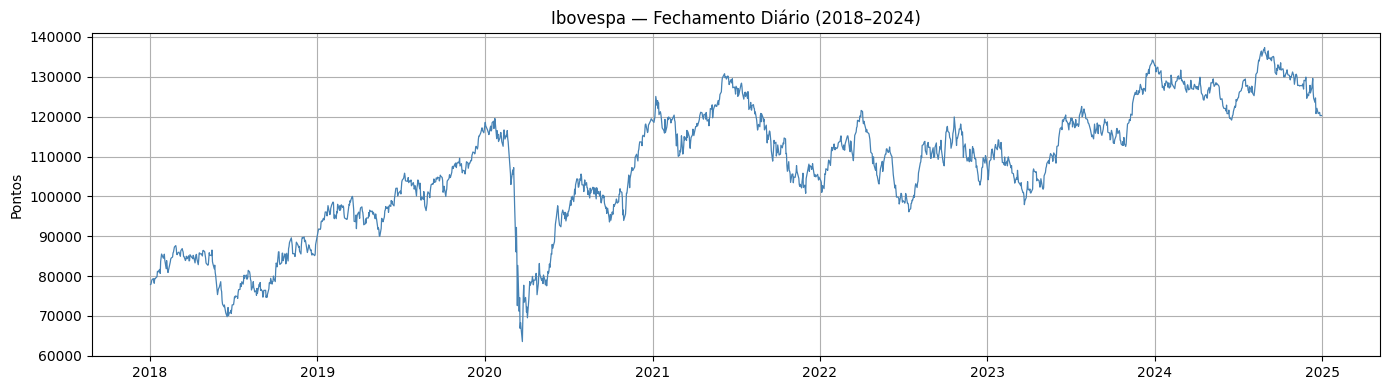

In [5]:
# Série completa
plt.figure(figsize=(14, 4))
plt.plot(df['fechamento'], color='steelblue', linewidth=0.9)
plt.title('Ibovespa — Fechamento Diário (2018–2024)')
plt.ylabel('Pontos')
plt.tight_layout()
plt.show()


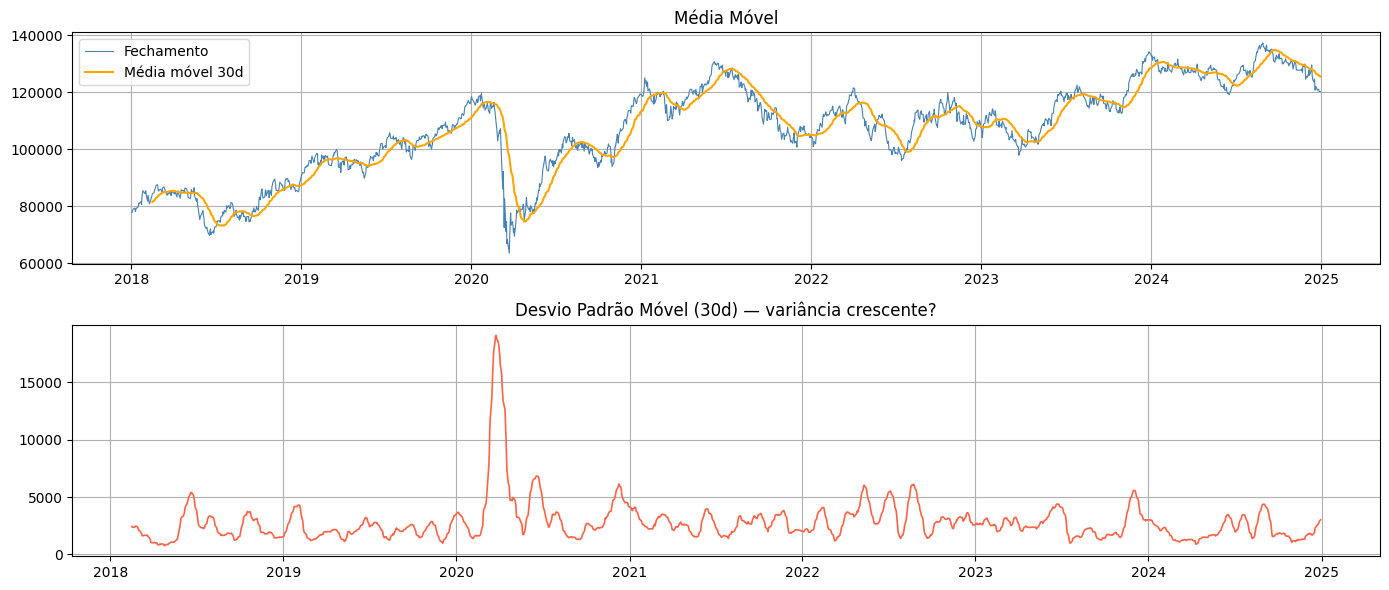

In [6]:
# Média e desvio padrão móveis (rolling 30 dias)
roll = df['fechamento'].rolling(30)

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(df['fechamento'], color='steelblue', linewidth=0.8, label='Fechamento')
axes[0].plot(roll.mean(), color='orange', linewidth=1.5, label='Média móvel 30d')
axes[0].set_title('Média Móvel')
axes[0].legend()

axes[1].plot(roll.std(), color='tomato', linewidth=1.2)
axes[1].set_title('Desvio Padrão Móvel (30d) — variância crescente?')

plt.tight_layout()
plt.show()


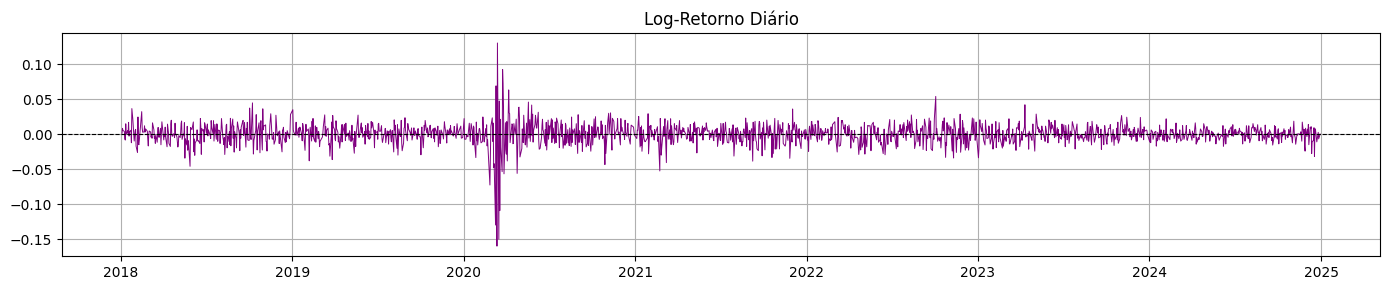

Maior queda:  -0.1599 em 2020-03-12
Maior alta:   0.1302 em 2020-03-13


In [7]:
# Log-retorno diário
df['log_retorno'] = np.log(df['fechamento'] / df['fechamento'].shift(1))

plt.figure(figsize=(14, 3))
plt.plot(df['log_retorno'], color='purple', linewidth=0.7)
plt.title('Log-Retorno Diário')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

print(f"Maior queda:  {df['log_retorno'].min():.4f} em {df['log_retorno'].idxmin().date()}")
print(f"Maior alta:   {df['log_retorno'].max():.4f} em {df['log_retorno'].idxmax().date()}")


## 🔬 Decomposição da Série

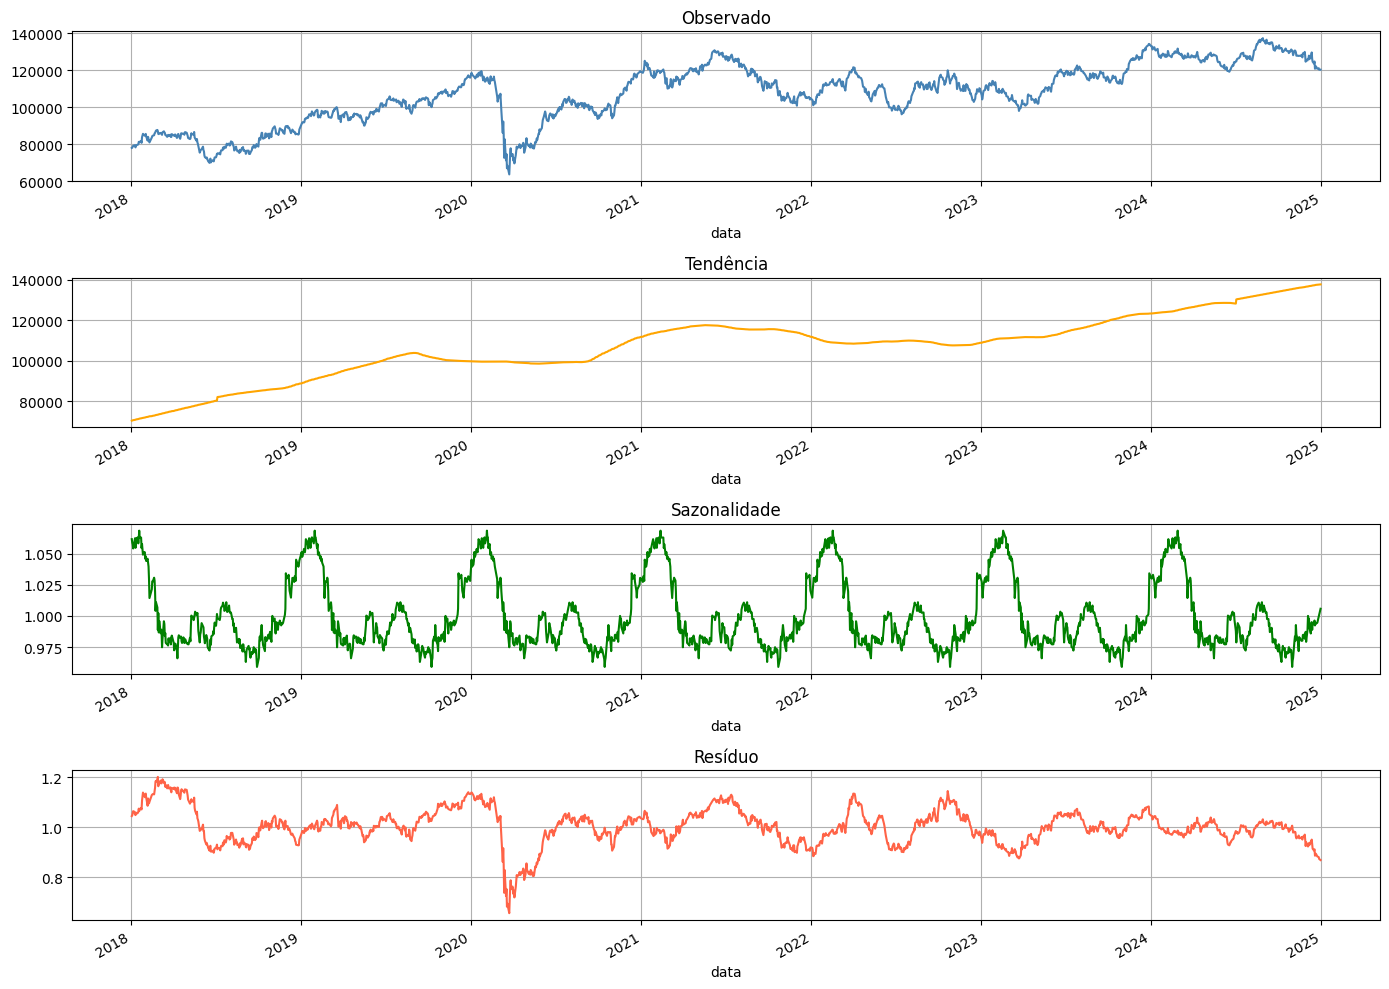

In [8]:
# Decomposição multiplicativa (252 dias úteis = 1 ano)
decomp = seasonal_decompose(df['fechamento'], model='multiplicative', period=252, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0], title='Observado', color='steelblue')
decomp.trend.plot(ax=axes[1], title='Tendência', color='orange')
decomp.seasonal.plot(ax=axes[2], title='Sazonalidade', color='green')
decomp.resid.plot(ax=axes[3], title='Resíduo', color='tomato')
plt.tight_layout()
plt.show()


##  Estacionariedade — Teste ADF

In [9]:
def teste_adf(serie, nome):
    resultado = adfuller(serie.dropna())
    print(f"{'='*50}")
    print(f"Série: {nome}")
    print(f"Estatística ADF : {resultado[0]:.4f}")
    print(f"p-valor         : {resultado[1]:.6f}")
    print(f"Conclusão       : {'✅ ESTACIONÁRIA' if resultado[1] <= 0.05 else '❌ NÃO ESTACIONÁRIA'}")

# Série original
teste_adf(df['fechamento'], 'Fechamento original')

# Log-retorno (1ª diferença do log)
teste_adf(df['log_retorno'], 'Log-retorno (1ª diferença do log)')


Série: Fechamento original
Estatística ADF : -2.4260
p-valor         : 0.134532
Conclusão       : ❌ NÃO ESTACIONÁRIA
Série: Log-retorno (1ª diferença do log)
Estatística ADF : -12.9371
p-valor         : 0.000000
Conclusão       : ✅ ESTACIONÁRIA


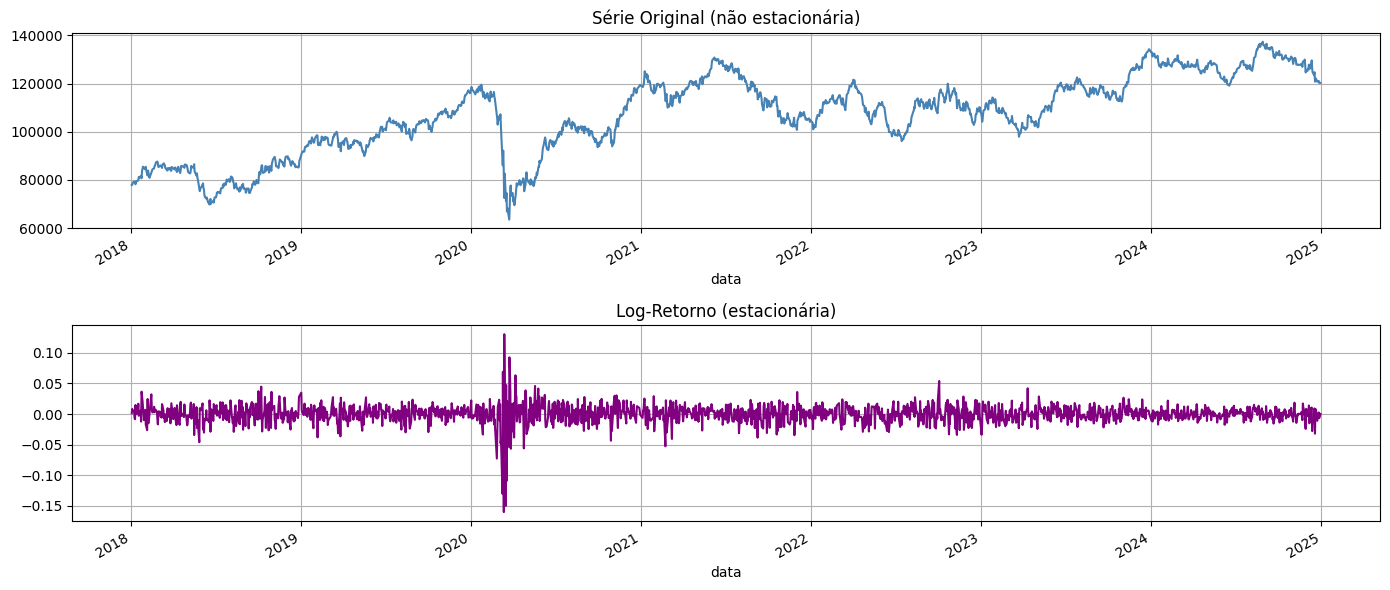

In [10]:
# Visualização: original vs log-retorno
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

df['fechamento'].plot(ax=axes[0], title='Série Original (não estacionária)', color='steelblue')
df['log_retorno'].dropna().plot(ax=axes[1], title='Log-Retorno (estacionária)', color='purple')

plt.tight_layout()
plt.show()


##  ACF e PACF

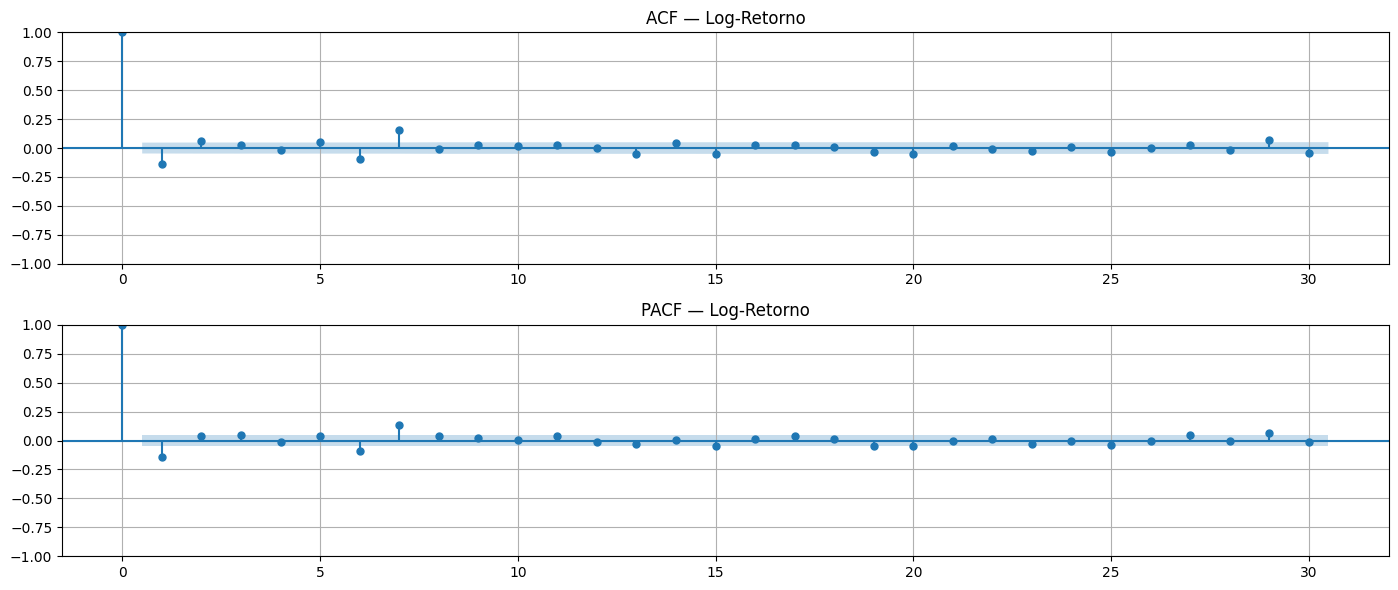

Interpretação: se ACF e PACF cortam rápido → pouca estrutura autocorrelacionada
Isso é esperado em séries financeiras (random walk)


In [11]:
serie_est = df['log_retorno'].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
plot_acf(serie_est, lags=30, ax=axes[0], title='ACF — Log-Retorno')
plot_pacf(serie_est, lags=30, ax=axes[1], title='PACF — Log-Retorno')
plt.tight_layout()
plt.show()

print("Interpretação: se ACF e PACF cortam rápido → pouca estrutura autocorrelacionada")
print("Isso é esperado em séries financeiras (random walk)")


## Divisão Treino / Teste

In [12]:
HORIZONTE = 30  # dias de teste

serie = df['fechamento'].dropna()
treino = serie.iloc[:-HORIZONTE]
teste  = serie.iloc[-HORIZONTE:]

print(f"Treino: {treino.index[0].date()} → {treino.index[-1].date()} ({len(treino)} obs)")
print(f"Teste:  {teste.index[0].date()}  → {teste.index[-1].date()}  ({len(teste)} obs)")


Treino: 2018-01-02 → 2024-11-12 (1707 obs)
Teste:  2024-11-13  → 2024-12-30  (30 obs)


## 🏁 Baseline — Média Móvel (21 dias)

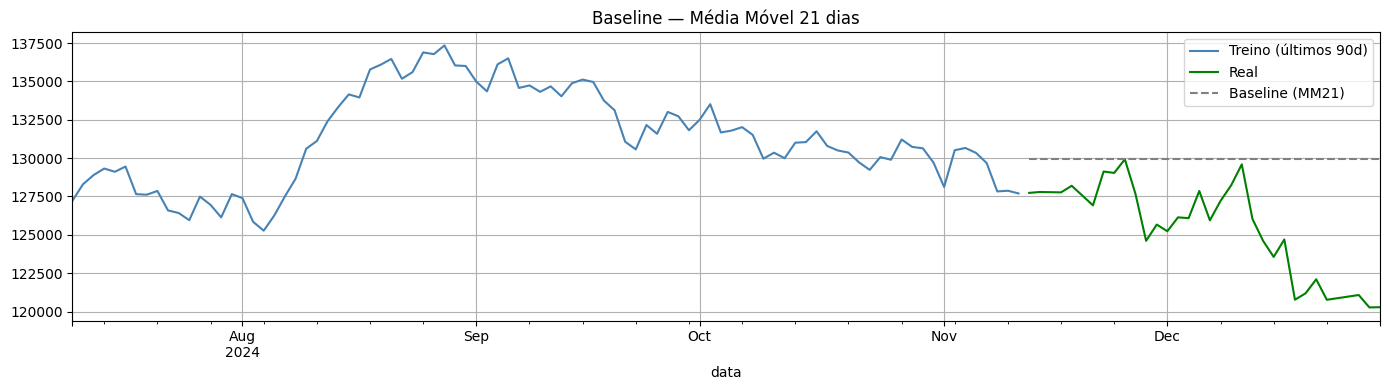

In [13]:
# Previsão ingênua: último valor da média móvel replicado
baseline_val = treino.rolling(21).mean().iloc[-1]
prev_baseline = pd.Series([baseline_val] * HORIZONTE, index=teste.index)

plt.figure(figsize=(14, 4))
treino.iloc[-90:].plot(label='Treino (últimos 90d)', color='steelblue')
teste.plot(label='Real', color='green')
prev_baseline.plot(label='Baseline (MM21)', color='gray', linestyle='--')
plt.title('Baseline — Média Móvel 21 dias')
plt.legend()
plt.tight_layout()
plt.show()


##  Modelo 1 — ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


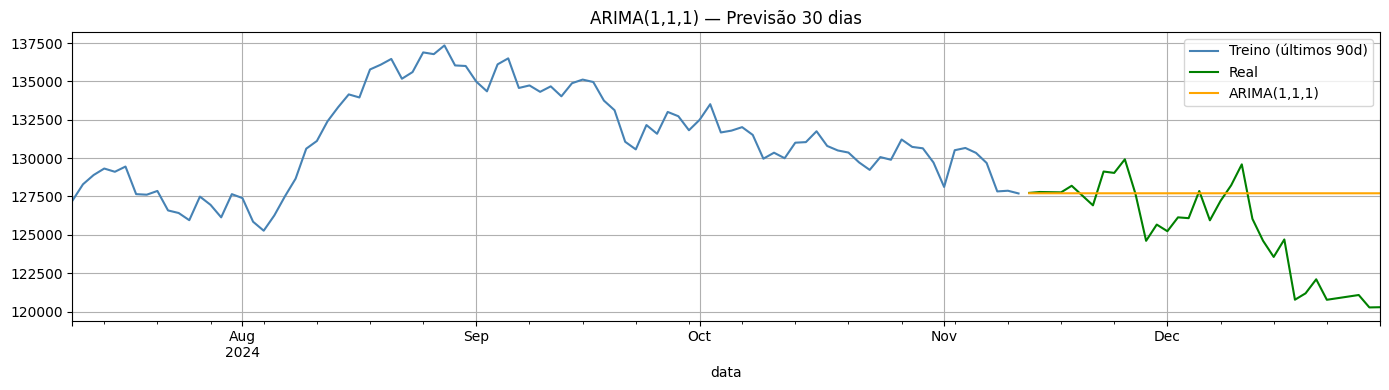

                               SARIMAX Results                                
Dep. Variable:             fechamento   No. Observations:                 1707
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -14875.137
Date:                Fri, 12 Jun 2026   AIC                          29756.273
Time:                        15:15:29   BIC                          29772.599
Sample:                             0   HQIC                         29762.316
                               - 1707                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2125      0.160     -1.326      0.185      -0.527       0.102
ma.L1          0.1582      0.163      0.972      0.331      -0.161       0.477
sigma2      2.189e+06   3.09e+04     70.726      0.0

In [14]:
# ARIMA(1,1,1) — d=1 pois série original não é estacionária
modelo_arima = ARIMA(treino, order=(1, 1, 1)).fit()
prev_arima = modelo_arima.forecast(steps=HORIZONTE)
prev_arima.index = teste.index

plt.figure(figsize=(14, 4))
treino.iloc[-90:].plot(label='Treino (últimos 90d)', color='steelblue')
teste.plot(label='Real', color='green')
prev_arima.plot(label='ARIMA(1,1,1)', color='orange')
plt.title('ARIMA(1,1,1) — Previsão 30 dias')
plt.legend()
plt.tight_layout()
plt.show()

print(modelo_arima.summary())


##  Modelo 2 — Prophet

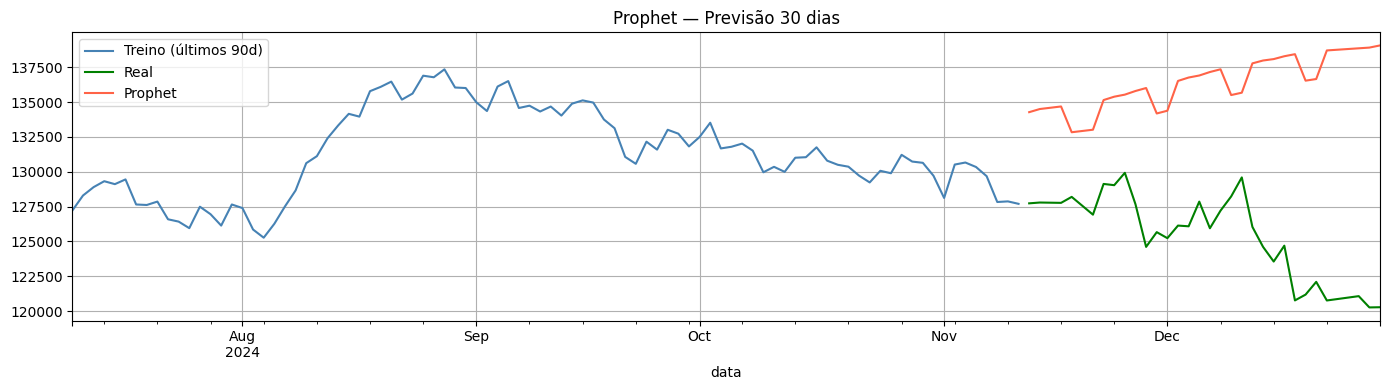

In [15]:
# Preparar dataframe no formato Prophet (ds, y)
df_prophet = treino.reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

# Treinar
m_prophet = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
m_prophet.fit(df_prophet)

# Prever
futuro = m_prophet.make_future_dataframe(periods=HORIZONTE)
forecast = m_prophet.predict(futuro)

# Extrair previsão do período de teste
prev_prophet = forecast.set_index('ds')['yhat'].iloc[-HORIZONTE:]
prev_prophet.index = teste.index

plt.figure(figsize=(14, 4))
treino.iloc[-90:].plot(label='Treino (últimos 90d)', color='steelblue')
teste.plot(label='Real', color='green')
prev_prophet.plot(label='Prophet', color='tomato')
plt.title('Prophet — Previsão 30 dias')
plt.legend()
plt.tight_layout()
plt.show()


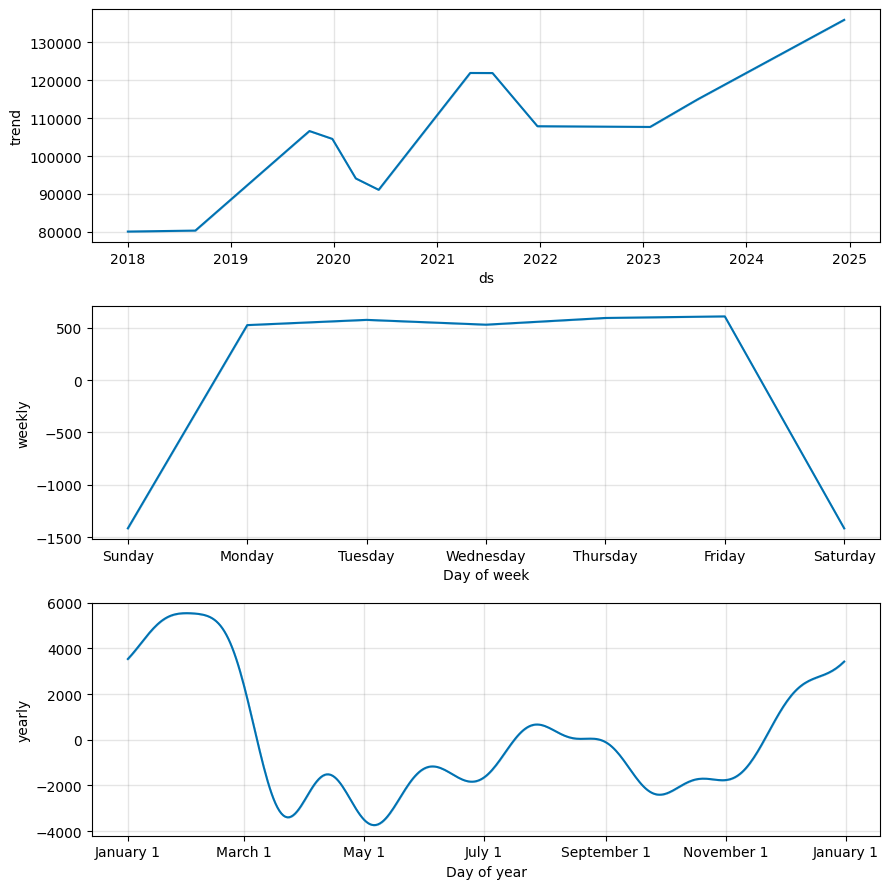

In [16]:
# Componentes do Prophet
fig = m_prophet.plot_components(forecast)
plt.tight_layout()
plt.show()


## 📏 Avaliação Comparativa — MAE / RMSE / MAPE

In [18]:
def metricas(nome, real, prev):
    mae  = mean_absolute_error(real, prev)
    rmse = np.sqrt(mean_squared_error(real, prev))
    mape = mean_absolute_percentage_error(real, prev) * 100
    return {'Modelo': nome, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE (%)': round(mape, 2)}

resultados = pd.DataFrame([
    metricas('Baseline (MM21)', teste, prev_baseline),
    metricas('ARIMA(1,1,1)',    teste, prev_arima),
    metricas('Prophet',         teste, prev_prophet),
])

resultados = resultados.sort_values('RMSE').reset_index(drop=True)
print(resultados.to_string(index=False))

         Modelo      MAE     RMSE  MAPE (%)
   ARIMA(1,1,1)  2715.86  3674.24      2.21
Baseline (MM21)  4385.70  5293.46      3.55
        Prophet 10822.63 11666.50      8.71


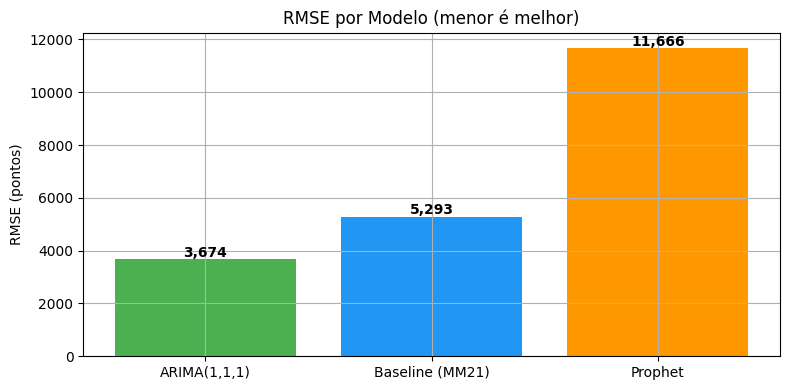

In [19]:
# Gráfico comparativo RMSE
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(resultados['Modelo'], resultados['RMSE'], color=['#4CAF50','#2196F3','#FF9800'])
ax.set_title('RMSE por Modelo (menor é melhor)')
ax.set_ylabel('RMSE (pontos)')
for i, v in enumerate(resultados['RMSE']):
    ax.text(i, v + 100, f'{v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


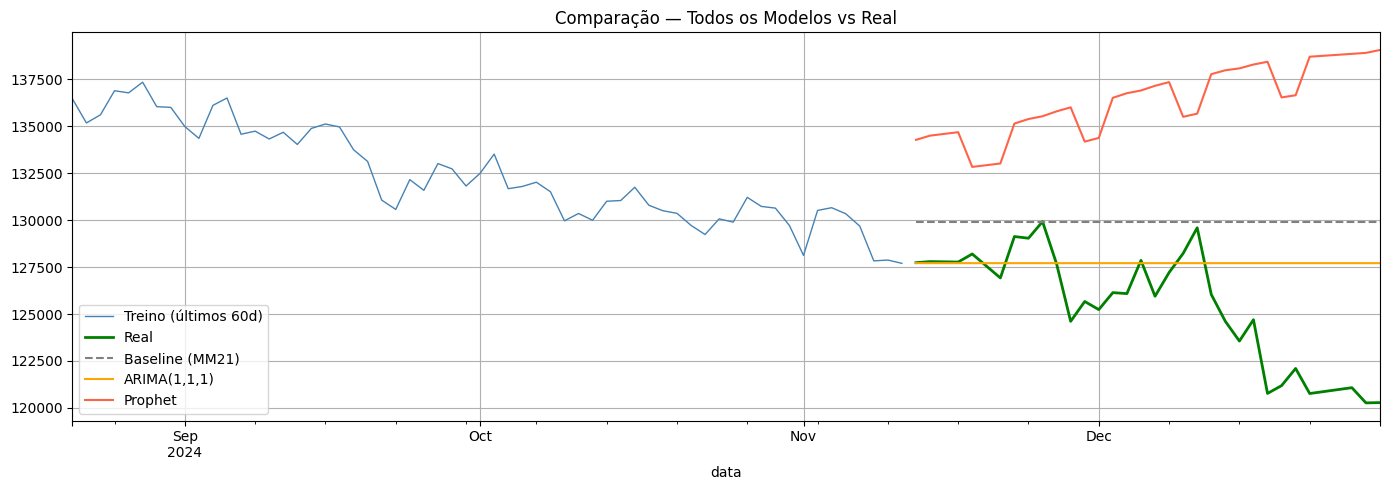

In [20]:
# Gráfico final: todos os modelos vs real
plt.figure(figsize=(14, 5))
treino.iloc[-60:].plot(label='Treino (últimos 60d)', color='steelblue', linewidth=1)
teste.plot(label='Real', color='green', linewidth=2)
prev_baseline.plot(label='Baseline (MM21)', color='gray', linestyle='--')
prev_arima.plot(label='ARIMA(1,1,1)', color='orange')
prev_prophet.plot(label='Prophet', color='tomato')
plt.title('Comparação — Todos os Modelos vs Real')
plt.legend()
plt.tight_layout()
plt.show()


## 📝 Conclusão

### Resultados

A comparação dos três modelos sobre os últimos 30 dias (13/11/2024 → 30/12/2024) produziu os seguintes resultados:

| Modelo         | MAE      | RMSE      | MAPE (%) |
|----------------|----------|-----------|----------|
| ARIMA(1,1,1)   | 2.715,86 | 3.674,24  | 2,21%    |
| Baseline (MM21)| 4.385,70 | 5.293,46  | 3,55%    |
| Prophet        | 10.822,63| 11.666,50 | 8,71%    |

O **ARIMA(1,1,1)** obteve o menor erro em todas as métricas, superando o baseline em ~31% no RMSE e o Prophet em ~68%.

---

### Por que o ARIMA venceu?

O Ibovespa se comporta como um **random walk**: o melhor palpite para amanhã é o valor de hoje. O ARIMA captura exatamente isso com d=1 (uma diferenciação). Sua vantagem não vem de ser sofisticado, mas de ser **conservador** — não tenta projetar tendências ou sazonalidades que não existem de forma estável.

---

### Por que o Prophet foi o pior?

O Prophet tentou ajustar sazonalidades semanal e anual. Em séries de negócio (vendas, energia) isso funciona bem. Em séries financeiras, esses padrões **não são estáveis** — o mercado é influenciado por eventos exógenos (decisões do Copom, eleições, crises) que nenhum modelo sazonal captura. Resultado: errou sistematicamente ao projetar uma tendência que não se confirmou.

---

### Limitações

- Séries financeiras são intrinsecamente difíceis de prever — nenhum modelo captura choques externos
- O ARIMA não é generalizável: em outro período de 30 dias, o resultado pode ser diferente
- Nenhum modelo usou variáveis externas (juros, câmbio, volume) que poderiam melhorar a previsão
- O horizonte de 30 dias é relativamente longo para séries tipo random walk — erros acumulam

---

### Aprendizados

- A **diferenciação (log-retorno)** é essencial para estacionarizar séries financeiras
- **ACF/PACF** que cortam rápido indicam random walk — expectativa de erro alto é natural
- Um **baseline simples** é difícil de superar e sempre deve ser o ponto de partida
- **Métricas no período de teste** (nunca no treino) são a única forma honesta de comparar modelos
